In [12]:
#import statements

import pandas as pd
import matplotlib.pyplot as plt

In [13]:
#Declaring of link to dataset
url = "https://raw.githubusercontent.com/frontiertechinstitute/datasets/refs/heads/main/AI%20and%20Digital%20Media/Global_AI_Content_Impact_Dataset.csv"
ai_df = pd.read_csv(url)
ai_df.info() #displaying basic information about the dataset

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 12 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Country                                     200 non-null    str    
 1   Year                                        200 non-null    int64  
 2   Industry                                    200 non-null    str    
 3   AI Adoption Rate (%)                        200 non-null    float64
 4   AI-Generated Content Volume (TBs per year)  200 non-null    float64
 5   Job Loss Due to AI (%)                      200 non-null    float64
 6   Revenue Increase Due to AI (%)              200 non-null    float64
 7   Human-AI Collaboration Rate (%)             200 non-null    float64
 8   Top AI Tools Used                           200 non-null    str    
 9   Regulation Status                           200 non-null    str    
 10  Consumer Trust in AI (%) 

In [14]:
ai_df.head(16)

,Country,Year,Industry,AI Adoption Rate (%),AI-Generated Content Volume (TBs per year),Job Loss Due to AI (%),Revenue Increase Due to AI (%),Human-AI Collaboration Rate (%),Top AI Tools Used,Regulation Status,Consumer Trust in AI (%),Market Share of AI Companies (%)
0,South Korea,2022,Media,44.29,33.09,16.77,46.12,74.79,Bard,Strict,40.77,18.73
1,China,2025,Legal,34.75,66.74,46.89,52.46,26.17,DALL-E,Strict,35.67,35.02
2,USA,2022,Automotive,81.06,96.13,10.66,45.60,39.66,Stable Diffusion,Moderate,54.47,22.76
3,France,2021,Legal,85.24,93.76,27.70,78.24,29.45,Claude,Moderate,51.84,1.93
4,France,2021,Gaming,78.95,45.62,17.45,1.05,21.70,Midjourney,Strict,41.77,21.41
5,USA,2021,Retail,66.95,47.72,0.86,27.58,64.42,ChatGPT,Lenient,68.14,8.09
6,Australia,2023,Media,68.23,6.14,6.20,53.13,53.16,Claude,Moderate,71.60,15.26
7,UK,2023,Gaming,91.27,33.87,41.67,56.26,59.93,ChatGPT,Moderate,46.98,28.51
8,Canada,2025,Education,17.02,87.77,4.59,52.45,64.72,Claude,Moderate,60.55,22.70
9,China,2025,Healthcare,25.50,18.74,15.07,40.81,64.86,Stable Diffusion,Moderate,51.07,39.97


In [15]:
ai_df['Top AI Tools Used'].info()

<class 'pandas.Series'>
RangeIndex: 200 entries, 0 to 199
Series name: Top AI Tools Used
Non-Null Count  Dtype
--------------  -----
200 non-null    str  
dtypes: str(1)
memory usage: 1.7 KB


In [16]:
first_valid_year= {
    'Bard': 2023,
    'ChatGPT': 2022,
    'Claude': 2023,
    'DALL-E': 2021,
    'Midjourney': 2022,
    'Stable Diffusion': 2022,
    'Synthesia': 2020
}
wrong_list = []
mismatch_count= 0

for i, row in ai_df.iterrows():
    tool = row['Top AI Tools Used']
    year = row['Year']
    
    if year < first_valid_year[tool]:
        mismatch_count += 1
        wrong_list.append(i)
        
    
        correct_year = first_valid_year[tool]
        ai_df.loc[i, 'Year'] = correct_year


print(mismatch_count)
print(wrong_list)
ai.head()






72
[0, 3, 4, 5, 12, 13, 26, 27, 30, 39, 40, 46, 47, 49, 51, 54, 60, 61, 65, 67, 71, 72, 74, 77, 80, 88, 89, 91, 94, 99, 101, 102, 106, 111, 112, 114, 119, 121, 122, 124, 126, 128, 134, 135, 136, 137, 138, 140, 141, 142, 144, 147, 148, 154, 158, 161, 162, 163, 165, 169, 170, 176, 178, 179, 180, 181, 184, 186, 189, 191, 196, 199]


,Country,Year,Industry,AI Adoption Rate (%),AI-Generated Content Volume (TBs per year),Job Loss Due to AI (%),Revenue Increase Due to AI (%),Human-AI Collaboration Rate (%),Top AI Tools Used,Regulation Status,Consumer Trust in AI (%),Market Share of AI Companies (%)
0,South Korea,2023,Media,44.29,33.09,16.77,46.12,74.79,Bard,Strict,40.77,18.73
1,China,2025,Legal,34.75,66.74,46.89,52.46,26.17,DALL-E,Strict,35.67,35.02
2,USA,2022,Automotive,81.06,96.13,10.66,45.60,39.66,Stable Diffusion,Moderate,54.47,22.76
3,France,2023,Legal,85.24,93.76,27.70,78.24,29.45,Claude,Moderate,51.84,1.93
4,France,2022,Gaming,78.95,45.62,17.45,1.05,21.70,Midjourney,Strict,41.77,21.41


In [17]:
mismatch_count = 0

for i, row in ai_df.iterrows():
    tool = row['Top AI Tools Used']
    year = row['Year']
    
    if year < first_valid_year[tool]:
        mismatch_count += 1

print(mismatch_count)


0


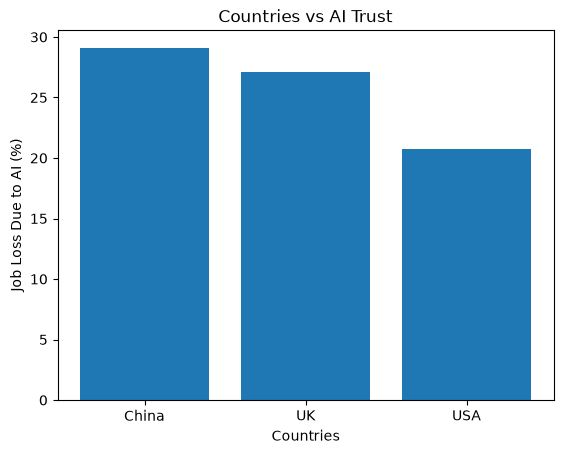

In [33]:
filtered_data = ai_df[ai_df['Country'].isin(['USA', 'China', 'UK'])]

# 2. Group by Country and calculate the mean for your filtered dataset
result = filtered_data.groupby('Country')['Job Loss Due to AI (%)'].mean().reset_index()

# 3. Use the aggregated results directly for your plot axes
x = result['Country']
y = result['Job Loss Due to AI (%)']
plt.bar(x, y)

plt.title("Countries vs AI Trust")
plt.xlabel("Countries")
plt.ylabel("Job Loss Due to AI (%)")
plt.xticks()

plt.show()